<a href="https://colab.research.google.com/github/ahsanuamal/Ikhsan-Romli/blob/main/Submission_Akhir_Klasifikasi_Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Input Nama]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt
import os

## Data Preparation

In [11]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ikhsanromli","key":"959583617137bb8511b42b8bbc200ed1"}'}

In [12]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
!kaggle datasets download -d duttadebadri/image-classification

Dataset URL: https://www.kaggle.com/datasets/duttadebadri/image-classification
License(s): CC0-1.0
image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


### Data Loading

In [13]:
import zipfile
localZip = '/content/image-classification.zip'
zipRef = zipfile.ZipFile(localZip, 'r')
zipRef.extractall('image-classification')
zipRef.close()

In [14]:
!pip install split-folders

In [15]:
base_dir = '/content/image-classification/images/images'
output_dir = 'output'

#### Split Dataset

In [16]:
import splitfolders
splitfolders.ratio(
    base_dir,
    output=output_dir,
    seed=20251107,
    ratio=(0.85, 0.10, 0.05)
)

Copying files: 35095 files [00:28, 1212.92 files/s]


In [17]:
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

In [18]:
def count_images(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return count

base_count = count_images(base_dir)
train_count = count_images(train_dir)
val_count = count_images(val_dir)
test_count = count_images(test_dir)

print(f"Train images     : {train_count}")
print(f"Validation images: {val_count}")
print(f"Test images      : {test_count}\n")
print(f"Total            : {train_count + val_count + test_count}")
print(f"Base dir count   : {base_count}")

Train images     : 29827
Validation images: 3509
Test images      : 1757

Total            : 35093
Base dir count   : 35093


### Data Preprocessing

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [20]:
img_height = 128
img_width = 128
batch_size = 32

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=50,
    shuffle=True,
    color_mode='rgb',
    class_mode='categorical',
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=50,
    shuffle=True,
    color_mode='rgb',
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=50,
    shuffle=True,
    color_mode='rgb',
    class_mode='categorical',
)

Found 29827 images belonging to 4 classes.
Found 3509 images belonging to 4 classes.
Found 1757 images belonging to 4 classes.


## Modelling

In [22]:
input_shape = (img_height, img_width, 3)
num_classes = len(train_generator.class_indices)

In [23]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load the Xception model with pre-trained weights on ImageNet
base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Build the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 31, 31,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add[0][0]       

 Total params: 21,912,620 (83.59 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Compile the Model

In [24]:
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Train dan Validation the Model

In [25]:
epochs = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 37/596 ━━━━━━━━━━━━━━━━━━━━ 3:29 374ms/step - accuracy: 0.6133 - loss: 0.9834

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


117/596 ━━━━━━━━━━━━━━━━━━━━ 2:55 366ms/step - accuracy: 0.7220 - loss: 0.7543

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


...

596/596 ━━━━━━━━━━━━━━━━━━━━ 273s 423ms/step - accuracy: 0.8039 - loss: 0.5476 - val_accuracy: 0.8760 - val_loss: 0.3529
Epoch 2/10
  1/596 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.8800 - loss: 0.5923

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8800 - loss: 0.5923 - val_accuracy: 0.8754 - val_loss: 0.3546
Epoch 3/10
539/596 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - accuracy: 0.8564 - loss: 0.3947

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


596/596 ━━━━━━━━━━━━━━━━━━━━ 268s 377ms/step - accuracy: 0.8568 - loss: 0.3946 - val_accuracy: 0.8834 - val_loss: 0.3328
Epoch 4/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8600 - loss: 0.4063 - val_accuracy: 0.8860 - val_loss: 0.3302
Epoch 5/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 216s 363ms/step - accuracy: 0.8606 - loss: 0.3783 - val_accuracy: 0.8866 - val_loss: 0.3361
Epoch 6/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9000 - loss: 0.2174 - val_accuracy: 0.8869 - val_loss: 0.3398
Epoch 7/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 256s 371ms/step - accuracy: 0.8729 - loss: 0.3539 - val_accuracy: 0.8880 - val_loss: 0.3358
Epoch 8/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8200 - loss: 0.4448 - val_accuracy: 0.8877 - val_loss: 0.3337
Epoch 9/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 219s 367ms/step - accuracy: 0.8738 - loss: 0.3487 - val_accuracy: 0.8851 - val_loss: 0.3324
Epoch 10/10
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8800 - loss: 0.3226 - va

## Evaluasi dan Visualisasi

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 481ms/step - accuracy: 0.9131 - loss: 0.2664
Test Loss: 0.2619
Test Accuracy: 0.9124


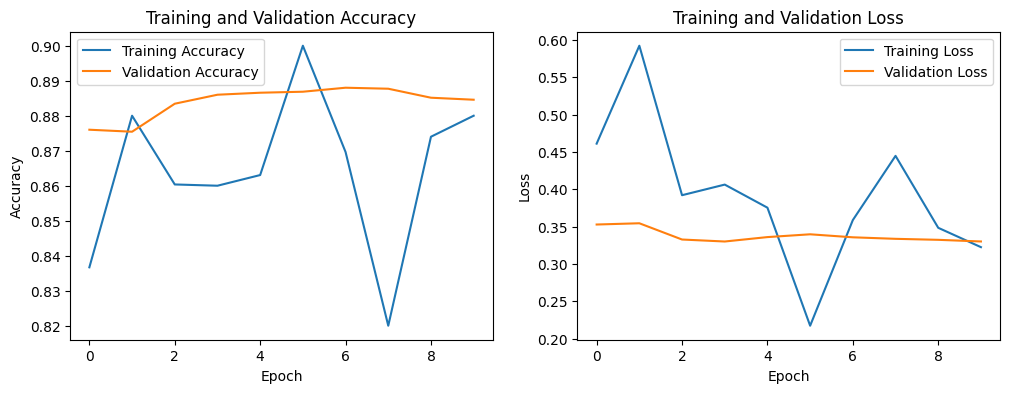

In [27]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Konversi Model

In [28]:
# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TensorFlow Lite model
with open('image_classification_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model converted and saved as image_classification_model.tflite")

Saved artifact at '/tmp/tmpjs4gmsvr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138916903176336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903177872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903179024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903179216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903181328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903178832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13891690318324

In [32]:
# Install tensorflowjs
!pip install tensorflowjs

# Save the model in SavedModel format
saved_model_dir = 'saved_model'
model.export(saved_model_dir)
print(f"Model saved in SavedModel format at: {saved_model_dir}")

# Convert the SavedModel to TensorFlow.js format
import tensorflowjs as tfjs

tfjs_target_dir = 'tfjs_model'
tfjs.converters.save_keras_model(model, tfjs_target_dir)
print(f"Model converted and saved in TensorFlow.js format at: {tfjs_target_dir}")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138916903176336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903177872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903179024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903179216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903181328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903180944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903178832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916903183248: Te

Model saved in SavedModel format at: saved_model
failed to lookup keras version from the file,
    this is likely a weight only file
Model converted and saved in TensorFlow.js format at: tfjs_model


In [ ]:
from google.colab import files
import os

# Download the .tflite file
tflite_file = 'image_classification_model.tflite'
if os.path.exists(tflite_file):
    files.download(tflite_file)
else:
    print(f"{tflite_file} not found.")

# Download the 'saved_model' directory
saved_model_dir = 'saved_model'
if os.path.exists(saved_model_dir):
    !zip -r /content/saved_model.zip /content/saved_model
    files.download('/content/saved_model.zip')
else:
    print(f"{saved_model_dir} not found.")

# Download the 'tfjs_model' directory
tfjs_model_dir = 'tfjs_model'
if os.path.exists(tfjs_model_dir):
    !zip -r /content/tfjs_model.zip /content/tfjs_model
    files.download('/content/tfjs_model.zip')
else:
    print(f"{tfjs_model_dir} not found.")

In [47]:
!zip -r '/content/tfjs_model.zip' '/content/tfjs_model'
from google.colab import files
files.download('/content/tfjs_model.zip')

updating: content/tfjs_model/ (stored 0%)
updating: content/tfjs_model/group1-shard7of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard17of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard12of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard16of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard10of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard6of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard11of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard3of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard8of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard2of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard18of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard1of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard19of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shard14of21.bin (deflated 7%)
updating: content/tfjs_model/group1-shar

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
!zip -r '/content/saved_model.zip' '/content/saved_model'
from google.colab import files
files.download('/content/saved_model.zip')

  adding: content/saved_model/ (stored 0%)
  adding: content/saved_model/assets/ (stored 0%)
  adding: content/saved_model/saved_model.pb (deflated 91%)
  adding: content/saved_model/variables/ (stored 0%)
  adding: content/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/saved_model/variables/variables.index (deflated 79%)
  adding: content/saved_model/fingerprint.pb (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
!zip -r '/content/image_classification_model.tflite.zip' '/content/image_classification_model.tflite'
from google.colab import files
files.download('/content/image_classification_model.tflite.zip')

  adding: content/image_classification_model.tflite (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>